# Classification + Uncertainty Demo

This notebook shows A4D's affordance classification and calibrated-uncertainty pipeline end to end, using the fine-tuned CLIP checkpoint:

1. **Single example walkthrough** — classify one image-affordance pair and inspect the raw output (embeddings, distances, predicted label).
2. **Calibration** — fit isotonic regressors that turn raw projection distance into a calibrated confidence score.
3. **Sanity check** — run the calibrated pipeline on several more (image, affordance) pairs, including one deliberate mistake, and check predictions + confidence against ground truth.

## 1. Single Example Walkthrough

Load the fine-tuned CLIP checkpoint and classify one image on one affordance, producing the raw embeddings, distances, and predicted label.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from IPython.display import Image as DisplayImage, display, HTML
from PIL import Image
from sklearn.isotonic import IsotonicRegression
from huggingface_hub import hf_hub_download

import open_clip

# Walk up from the current working directory to find the repo root, so this
# works whether the notebook is launched from the repo root or elsewhere.
def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "affordance_gen" / "affordance_gen.py").is_file():
            return p
    raise FileNotFoundError(
        "Could not find repo root (expected affordance_gen/affordance_gen.py)."
    )

ROOT = find_repo_root()

# The fine-tuned checkpoint (~577MB) lives on Hugging Face, not in this repo.
# Use a local copy if you happen to have one (e.g. ROOT/A4D_model.pt),
# otherwise download it from the Hub.
CHECKPOINT_REPO = "rohansiva/A4D-Checkpoint"
CHECKPOINT_FILENAME = "A4D_model.pt"
LOCAL_CHECKPOINT_PATH = ROOT / CHECKPOINT_FILENAME

if LOCAL_CHECKPOINT_PATH.is_file():
    CHECKPOINT_PATH = LOCAL_CHECKPOINT_PATH
else:
    print(f"Checkpoint not found locally, downloading from https://huggingface.co/{CHECKPOINT_REPO} ...")
    CHECKPOINT_PATH = Path(hf_hub_download(repo_id=CHECKPOINT_REPO, filename=CHECKPOINT_FILENAME))

IMAGE_PATH = ROOT / "dataset" / "chair_014.jpg"
UNCERTAINTY_RESULTS_PATH = ROOT / "affordance_classification" / "uncertainty" / "uncertainty_results.json"

AFFORDANCE = "supportable"

AFFORDANCE_ANTONYMS = {
    "graspable": "slippery",
    "movable": "anchored",
    "stackable": "wobbly",
    "supportable": "fragile",
    "liftable": "heavy",
    "rollable": "fixed",
    "openable": "sealed",
    "containable": "solid",
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
print("checkpoint:", CHECKPOINT_PATH)
print("image:", IMAGE_PATH)

Checkpoint not found locally, downloading from https://huggingface.co/rohansiva/A4D-Checkpoint ...
device: cpu
checkpoint: /Users/rohansiva/.cache/huggingface/hub/models--rohansiva--A4D-Checkpoint/snapshots/5510fc8aed96a18b1b26eaf5ffff7a9539911454/A4D_model.pt
image: /Users/rohansiva/Desktop/a4dance-reasoning.github.io/dataset/chair_014.jpg


In [2]:
def load_finetuned_clip(checkpoint_path=CHECKPOINT_PATH, device=DEVICE):
    model, _, preprocess = open_clip.create_model_and_transforms(
        "ViT-B-32",
        pretrained="openai",
    )

    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
    model.load_state_dict(state_dict)
    model = model.to(device).eval()

    tokenizer = open_clip.get_tokenizer("ViT-B-32")
    return model, preprocess, tokenizer


model, preprocess, tokenizer = load_finetuned_clip()
print("loaded fine-tuned CLIP")

/opt/anaconda3/lib/python3.11/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


loaded fine-tuned CLIP


In [3]:
def classify_affordance_with_embeddings(image_path, affordance, model, preprocess, tokenizer, device=DEVICE):
    """Return classification output plus embeddings and uncertainty-compatible distances."""
    image_path = Path(image_path)

    if affordance not in AFFORDANCE_ANTONYMS:
        raise ValueError(f"Unknown affordance {affordance!r}; known: {sorted(AFFORDANCE_ANTONYMS)}")

    antonym = AFFORDANCE_ANTONYMS[affordance]

    with torch.no_grad():
        image = Image.open(image_path).convert("RGB")
        image_tensor = preprocess(image).unsqueeze(0).to(device)
        text_tokens = tokenizer([affordance, antonym]).to(device)

        image_embedding = F.normalize(model.encode_image(image_tensor), dim=-1)
        text_embeddings = F.normalize(model.encode_text(text_tokens), dim=-1)

        affordance_embedding = text_embeddings[0]
        antonym_embedding = text_embeddings[1]

        sims = (image_embedding @ text_embeddings.T).squeeze(0)
        sim_affordance = float(sims[0].item())
        sim_antonym = float(sims[1].item())

    dist_to_affordance = 1.0 - sim_affordance
    dist_to_antonym = 1.0 - sim_antonym
    pred_label = int(sim_affordance > sim_antonym)

    return {
        "image": str(image_path),
        "object class": image_path.stem.rsplit("_", 1)[0],
        "affordance name": affordance,
        "antonym": antonym,
        "pred label": pred_label,
        "classification": "yes" if pred_label == 1 else "no",
        "dist to affordance": dist_to_affordance,
        "dist to antonym": dist_to_antonym,
        "scores": {
            "affordance_similarity": sim_affordance,
            "antonym_similarity": sim_antonym,
            "margin": sim_affordance - sim_antonym,
        },
        "embeddings": {
            "image": image_embedding.squeeze(0).cpu().tolist(),
            "affordance": affordance_embedding.cpu().tolist(),
            "antonym": antonym_embedding.cpu().tolist(),
        },
    }

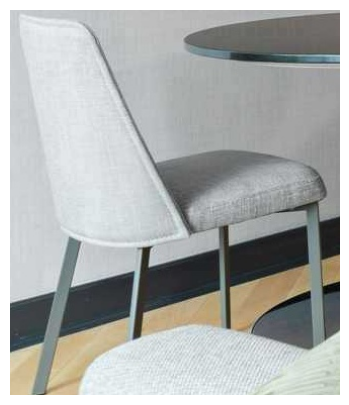

{
  "image": "/Users/rohansiva/Desktop/a4dance-reasoning.github.io/dataset/chair_014.jpg",
  "object class": "chair",
  "affordance name": "supportable",
  "antonym": "fragile",
  "pred label": 1,
  "classification": "yes",
  "dist to affordance": 0.7621850967407227,
  "dist to antonym": 0.7989510893821716,
  "scores": {
    "affordance_similarity": 0.23781490325927734,
    "antonym_similarity": 0.20104891061782837,
    "margin": 0.036765992641448975
  },
  "embeddings": {
    "image": "512 floats",
    "affordance": "512 floats",
    "antonym": "512 floats"
  }
}


In [4]:
img = Image.open(IMAGE_PATH).convert("RGBA")
white_bg = Image.new("RGBA", img.size, "WHITE")
white_bg.paste(img, mask=img.getchannel("A"))
img = white_bg.convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

classification_record = classify_affordance_with_embeddings(
    IMAGE_PATH,
    AFFORDANCE,
    model,
    preprocess,
    tokenizer,
)

# Full record includes three 512-d embeddings; keep the visible preview compact.
preview = dict(classification_record)
preview["embeddings"] = {k: f"{len(v)} floats" for k, v in classification_record["embeddings"].items()}

print(json.dumps(preview, indent=2))

## 2. Calibration

Raw projection distance isn't a calibrated confidence score on its own. To turn it into one, we first look at how `dist to affordance` and `dist to antonym` are distributed across a held-out calibration set, split by ground-truth and predicted label.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option

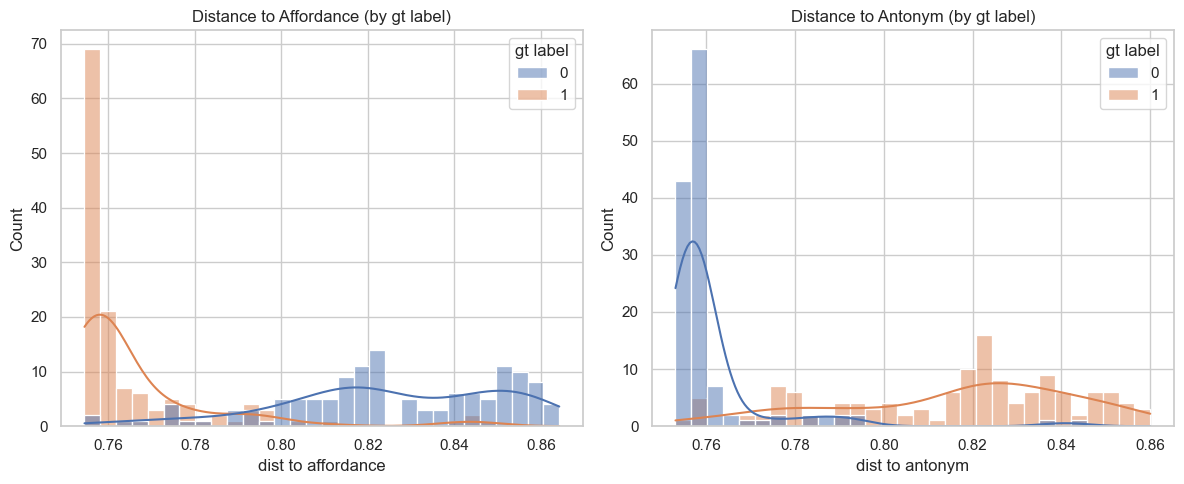

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option

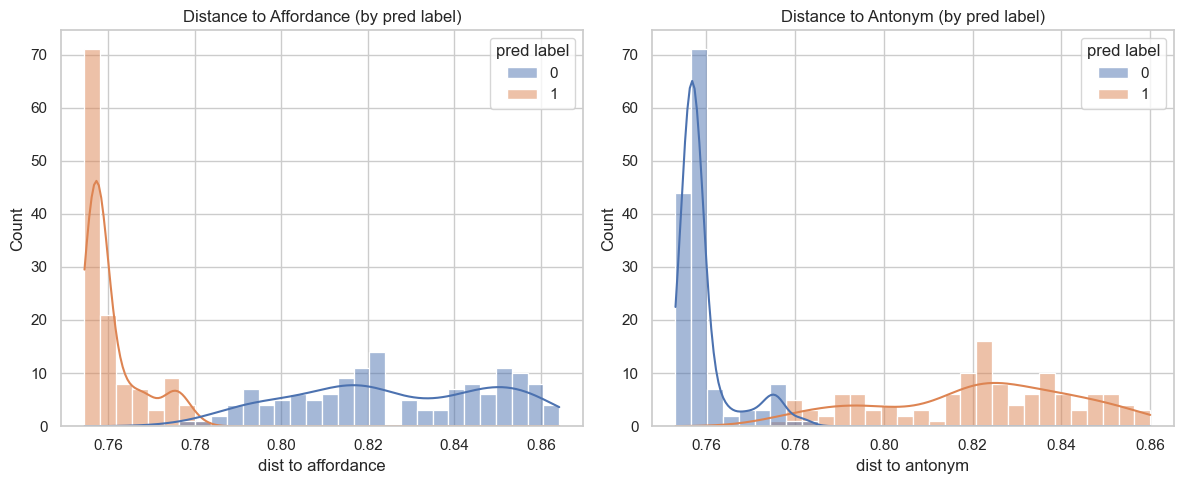

In [5]:
def load_calibration_data(path=UNCERTAINTY_RESULTS_PATH):
    with open(path, "r") as f:
        data_raw = json.load(f)

    # Match affordance_classification/uncertainty/uncertainty.ipynb.
    return data_raw["A (test img,   train aff)"] + data_raw["C (unseen cls, train aff)"]


def plot_distance_distributions(data, group_by="gt label"):
    if group_by not in ["gt label", "pred label"]:
        raise ValueError("group_by must be 'gt label' or 'pred label'")

    df = pd.DataFrame(data)
    sns.set(style="whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.histplot(data=df, x="dist to affordance", hue=group_by, bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f"Distance to Affordance (by {group_by})")

    sns.histplot(data=df, x="dist to antonym", hue=group_by, bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"Distance to Antonym (by {group_by})")

    plt.tight_layout()
    plt.show()


calibration_data = load_calibration_data()
plot_distance_distributions(calibration_data)
plot_distance_distributions(calibration_data, group_by="pred label")

### Fit the calibrators

We fit one isotonic regressor for positive predictions (using `dist to affordance`) and one for negative predictions (using `dist to antonym`), mapping raw distance to `Pr(correct)`. Applying that to our single example above adds `estimated_accuracy` and `uncertainty` to the record.

In [6]:
def fit_class_conditional_calibrator(data):
    df = pd.DataFrame(data)

    df_pos = df[df["pred label"] == 1]
    iso_pos = IsotonicRegression(out_of_bounds="clip")
    iso_pos.fit(-df_pos["dist to affordance"], (df_pos["gt label"] == 1).astype(int))

    df_neg = df[df["pred label"] == 0]
    iso_neg = IsotonicRegression(out_of_bounds="clip")
    iso_neg.fit(-df_neg["dist to antonym"], (df_neg["gt label"] == 0).astype(int))

    return iso_pos, iso_neg


def estimate_uncertainty(record, iso_pos, iso_neg):
    if record["pred label"] == 1:
        distance = record["dist to affordance"]
        estimated_accuracy = float(iso_pos.predict([-distance])[0])
    else:
        distance = record["dist to antonym"]
        estimated_accuracy = float(iso_neg.predict([-distance])[0])

    return {
        **record,
        "calibration distance used": distance,
        "estimated_accuracy": estimated_accuracy,
        "uncertainty": 1.0 - estimated_accuracy,
    }


iso_pos, iso_neg = fit_class_conditional_calibrator(calibration_data)

classification_uncertainty_record = estimate_uncertainty(classification_record, iso_pos, iso_neg)

preview = dict(classification_uncertainty_record)
preview["embeddings"] = {k: f"{len(v)} floats" for k, v in classification_uncertainty_record["embeddings"].items()}

print(json.dumps(preview, indent=2))

score = preview["estimated_accuracy"]
affordance = preview["affordance name"]
antonym = preview["antonym"]

if score > 0.7:
    conclusion = f"highly certain that the object is {affordance}"
elif score < 0.3:
    conclusion = f"highly certain that the object is {antonym}"
else:
    conclusion = "high uncertainty"

display(HTML(
    f"<p style='font-size:22px; font-weight:700;'>"
    f"Conclusion: uncertainty score = {score:.3f}; {conclusion}."
    f"</p>"
))

{
  "image": "/Users/rohansiva/Desktop/a4dance-reasoning.github.io/dataset/chair_014.jpg",
  "object class": "chair",
  "affordance name": "supportable",
  "antonym": "fragile",
  "pred label": 1,
  "classification": "yes",
  "dist to affordance": 0.7621850967407227,
  "dist to antonym": 0.7989510893821716,
  "scores": {
    "affordance_similarity": 0.23781490325927734,
    "antonym_similarity": 0.20104891061782837,
    "margin": 0.036765992641448975
  },
  "embeddings": {
    "image": "512 floats",
    "affordance": "512 floats",
    "antonym": "512 floats"
  },
  "calibration distance used": 0.7621850967407227,
  "estimated_accuracy": 0.9295628408446327,
  "uncertainty": 0.0704371591553673
}


## 3. Sanity Check: Multiple Samples

The single chair/`supportable` example above is illustrative, but one prediction doesn't show whether the checkpoint is actually accurate — or whether its calibrated confidence is meaningful. Here we run a fixed, hand-picked set of (image, affordance) pairs from `dataset/`, apply the same isotonic calibrators fit above (`iso_pos`, `iso_neg`), and compare both the raw prediction and the calibrated confidence against the known-correct label.

The last row is deliberately a **mistake**: `stairs_004.jpg` on `supportable` is mispredicted, but its raw margin is almost exactly zero and its calibrated confidence (0.333) correctly lands in the "uncertain" band rather than being falsely confident — showing that calibration isn't just decorative, it's actually tracking when the model doesn't know.

In [7]:
sample_records = [
    {"image": "hammer_015.jpg", "affordance": "rollable", "label": 0},
    {"image": "frame865_banana.jpg", "affordance": "containable", "label": 0},
    {"image": "bin_016.jpg", "affordance": "liftable", "label": 0},
    {"image": "chair_012.jpg", "affordance": "supportable", "label": 1},
    {"image": "pan_005.jpg", "affordance": "movable", "label": 1},
    {"image": "stairs_004.jpg", "affordance": "supportable", "label": 1},
]

rows = []
num_correct = 0
for r in sample_records:
    image_path = ROOT / "dataset" / r["image"]
    result = classify_affordance_with_embeddings(image_path, r["affordance"], model, preprocess, tokenizer)
    calibrated = estimate_uncertainty(result, iso_pos, iso_neg)
    is_correct = result["pred label"] == r["label"]
    num_correct += int(is_correct)
    rows.append({
        "image": r["image"],
        "affordance": r["affordance"],
        "predicted": result["pred label"],
        "ground truth": r["label"],
        "match": "\u2713" if is_correct else "\u2717",
        "margin (raw)": round(result["scores"]["margin"], 3),
        "calibrated confidence": round(calibrated["estimated_accuracy"], 3),
    })

sample_df = pd.DataFrame(rows)
display(sample_df)
print(f"\n{num_correct}/{len(rows)} correct ({num_correct / len(rows):.0%}) on this sample")
print(f"Mean calibrated confidence on correct predictions: {sample_df.loc[sample_df['match'] == chr(0x2713), 'calibrated confidence'].mean():.3f}")
print(f"Calibrated confidence on the one mistake: {sample_df.loc[sample_df['match'] != chr(0x2713), 'calibrated confidence'].values}")

,image,affordance,predicted,ground truth,match,margin (raw),calibrated confidence
0,hammer_015.jpg,rollable,0,0,✓,-0.027,0.900
1,frame865_banana.jpg,containable,0,0,✓,-0.036,0.900
2,bin_016.jpg,liftable,0,0,✓,-0.031,0.900
3,chair_012.jpg,supportable,1,1,✓,0.038,0.961
4,pan_005.jpg,movable,1,1,✓,0.024,0.961
5,stairs_004.jpg,supportable,0,1,✗,-0.001,0.333



5/6 correct (83%) on this sample
Mean calibrated confidence on correct predictions: 0.924
Calibrated confidence on the one mistake: [0.333]
